# 18 · `shapes`

`Map.shapes` draws polygon outlines only (no fill) — for boundaries/footprints (cleopatra `PolygonGlyph`, outline mode).

**Setup** — inline plots and the path to the bundled Lisbon DEM.

In [1]:
%matplotlib inline
from pathlib import Path

# Locate the bundled Lisbon DEM from the repo root (works from docs/ or the repo root).
ROOT = Path.cwd()
while not (ROOT / "examples" / "data" / "LisbonElevation.tif").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
DEM = str(ROOT / "examples" / "data" / "LisbonElevation.tif")
from pyramids.dataset import Dataset
from digitalearth.scene import Map
ds = Dataset.read_file(DEM)
coarse = ds.resample(ds.cell_size * 10)   # downsample for legible markers/cells
cells = coarse.get_cell_polygons()
cells['elevation'] = coarse.read_array(band=0).astype('float64').ravel()

Draw the cell polygons as outlines.

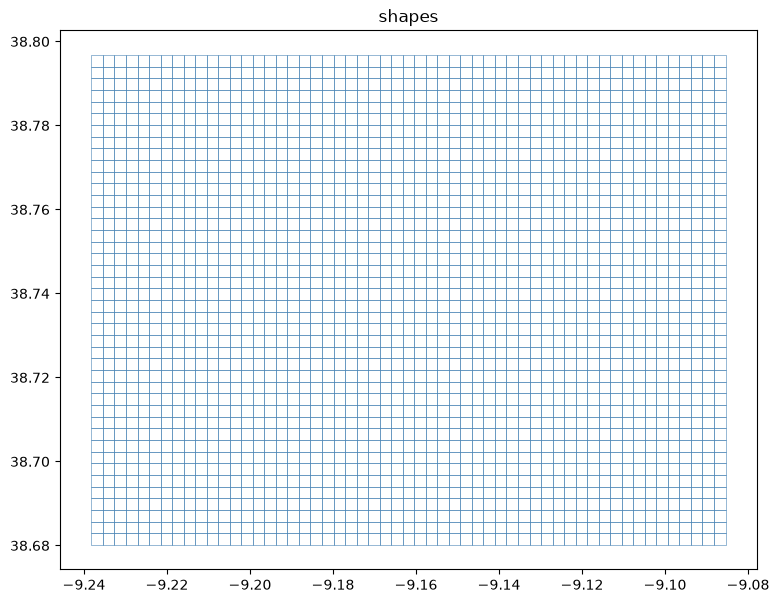

In [2]:
m = Map(crs=coarse.epsg, figsize=(9, 7))
m.shapes(cells, edgecolor='steelblue', linewidth=0.4)
m.set_title('shapes')
m.fig;